<img src="https://raw.githubusercontent.com/karolapalomino15-tech/Imagenes/main/WhatsApp%20Image%202026-05-01%20at%204.12.39%20PM%20(1).jpeg" width="550" height="250">

# <center> *Clasificacion de Compradores Online segun su Comportamiento*
Integrantes:
*   Karol Yamile Palomino Prada
*   Pedro Isaac Estupiñan Rodriguez
*   Giselle Alejandra Vesga Romero


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, make_scorer, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
print('TF version:', tf.__version__)

TF version: 2.20.0


---
## PRIMERA ENTREGA

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1jbJ7tNcpfo6d8n8_F32ZY9cdQMi224CE')
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.drop(columns=['OperatingSystems', 'Browser', 'Region', 'TrafficType'], inplace=True)

In [ ]:
Q1_pr = df['ProductRelated'].quantile(0.25)
Q3_pr = df['ProductRelated'].quantile(0.75)
IQR_pr = Q3_pr - Q1_pr

limite_inferior_pr = max(0, Q1_pr - 1.5 * IQR_pr)
limite_superior_pr = Q3_pr + 1.5 * IQR_pr

outliers_pr = df[(df['ProductRelated'] < limite_inferior_pr) | (df['ProductRelated'] > limite_superior_pr)]

print(f"ProductRelated - Q1: {Q1_pr}, Q3: {Q3_pr}, IQR: {IQR_pr}")
print(f"Límite inferior: {limite_inferior_pr}, Límite superior: {limite_superior_pr}")
print(f"Outliers encontrados: {len(outliers_pr)}")

ProductRelated - Q1: 7.0, Q3: 38.0, IQR: 31.0
Límite inferior: 0, Límite superior: 84.5
Outliers encontrados: 987


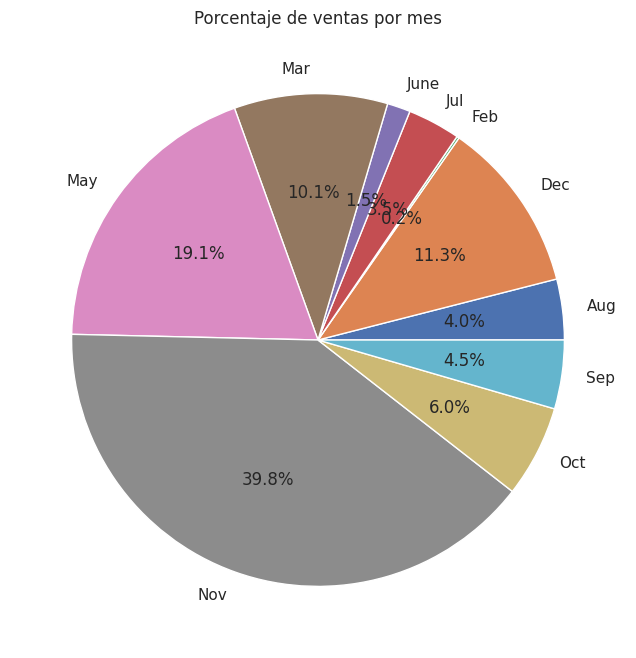

In [ ]:
ventas_por_mes = df[df['Revenue'] == True].groupby('Month')['Revenue'].count()

plt.figure(figsize=(8, 8))
plt.pie(ventas_por_mes, labels=ventas_por_mes.index, autopct='%1.1f%%')
plt.title('Porcentaje de ventas por mes')
plt.show()

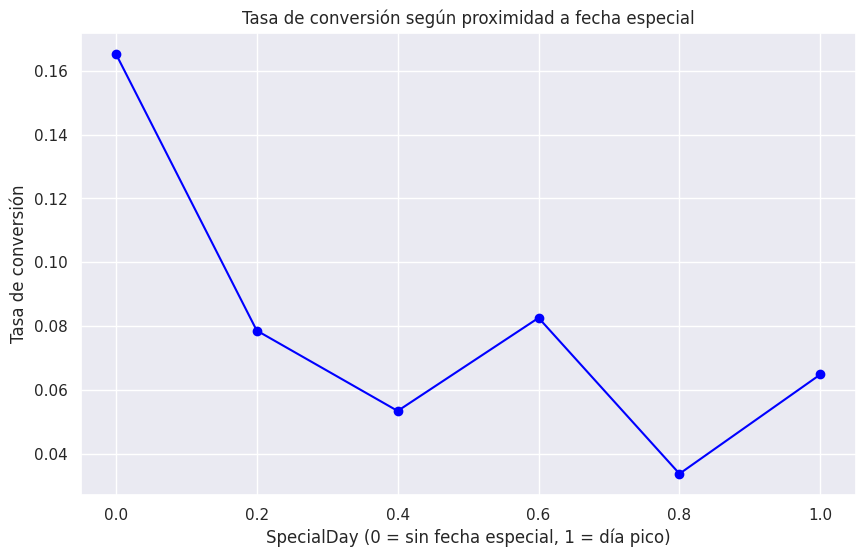

In [ ]:
special = df.groupby('SpecialDay')['Revenue'].mean()

plt.figure(figsize=(10, 6))
plt.plot(special.index, special.values, marker='o', color='blue')

plt.title('Tasa de conversión según proximidad a fecha especial')
plt.xlabel('SpecialDay (0 = sin fecha especial, 1 = día pico)')
plt.ylabel('Tasa de conversión')
plt.show()

---
##SEGUNDA ENTREGA

In [ ]:
#df.drop(columns=['VisitorType', 'Month'], inplace=True)
print('Columnas restantes:', df.columns.tolist())

Columnas restantes: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'VisitorType', 'Weekend', 'Revenue']


In [ ]:
# 1.1 Valores nulos / NaN
print('Valores nulos por columna:')
print(df.isnull().sum())
print('Total NaN:', df.isnull().sum().sum())
df.dropna(inplace=True)
print('Shape tras eliminar NaN:', df.shape)

Valores nulos por columna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
Total NaN: 0
Shape tras eliminar NaN: (12330, 14)


In [ ]:
# 1.2 Filas duplicadas
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')
df.drop_duplicates(inplace=True)
print('Shape final:', df.shape)

Filas duplicadas: 600
Shape final: (11730, 14)


In [ ]:
# 1.3 Convertir Revenue (bool) a int
df['Revenue'] = df['Revenue'].astype(int)
print('Distribucion de clases:')
print(df['Revenue'].value_counts())
df['VisitorType']=pd.factorize(df['VisitorType'])[0]
df['Month']=pd.factorize(df['Month'])[0]
df.describe()

Distribucion de clases:
Revenue
0    9822
1    1908
Name: count, dtype: int64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,VisitorType,Revenue
count,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000,11730.000000
mean,2.433504,84.952555,0.529156,36.235692,33.291645,1255.822881,0.013420,0.035196,6.190499,0.062387,4.592668,0.155413,0.162660
std,3.363157,180.272791,1.296997,144.082853,45.046827,1942.369830,0.028767,0.034527,18.988405,0.200601,2.972546,0.379103,0.369071
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,228.000000,0.000000,0.013562,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,14.625000,0.000000,0.000000,19.000000,655.539286,0.002151,0.024516,0.000000,0.000000,4.000000,0.000000,0.000000
75%,4.000000,99.000000,0.000000,0.000000,39.000000,1540.510029,0.014164,0.043145,0.000000,0.000000,7.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,9.000000,2.000000,1.000000


---
## 2. Particionado 80/20 con shuffle

In [ ]:
X = df.values[:, :-1]
y = df.values[:, -1].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, shuffle=True
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Proporcion train: {len(X_train)/len(X)*100:.1f}%  test: {len(X_test)/len(X)*100:.1f}%')

Train: (9384, 13)  |  Test: (2346, 13)
Proporcion train: 80.0%  test: 20.0%


---
## 3. Decision Tree Classifier  (tuning: max_depth)

In [ ]:
depths = [2,3,4,5,6,7,8,9,10]
dt_results = {}

for d in depths:
    est = DecisionTreeClassifier(max_depth=d, random_state=21)
    est.fit(X_train, y_train)
    acc = accuracy_score(est.predict(X_test), y_test)
    dt_results[str(d)] = acc
    print(f'  max_depth={str(d):>5} -> accuracy = {acc:.4f}')

best_depth_idx = int(np.argmax(list(dt_results.values())))
best_depth = depths[best_depth_idx]
print(f'\nMejor max_depth: {best_depth}')

  max_depth=    2 -> accuracy = 0.8819
  max_depth=    3 -> accuracy = 0.8819
  max_depth=    4 -> accuracy = 0.8943
  max_depth=    5 -> accuracy = 0.8900
  max_depth=    6 -> accuracy = 0.8917
  max_depth=    7 -> accuracy = 0.8875
  max_depth=    8 -> accuracy = 0.8819
  max_depth=    9 -> accuracy = 0.8811
  max_depth=   10 -> accuracy = 0.8785

Mejor max_depth: 4


In [ ]:
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=21)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)

print('=== Decision Tree - Reporte de Clasificacion ===')
print(classification_report(y_test, y_pred_dt))

=== Decision Tree - Reporte de Clasificacion ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1949
           1       0.74      0.58      0.65       397

    accuracy                           0.89      2346
   macro avg       0.83      0.77      0.79      2346
weighted avg       0.89      0.89      0.89      2346



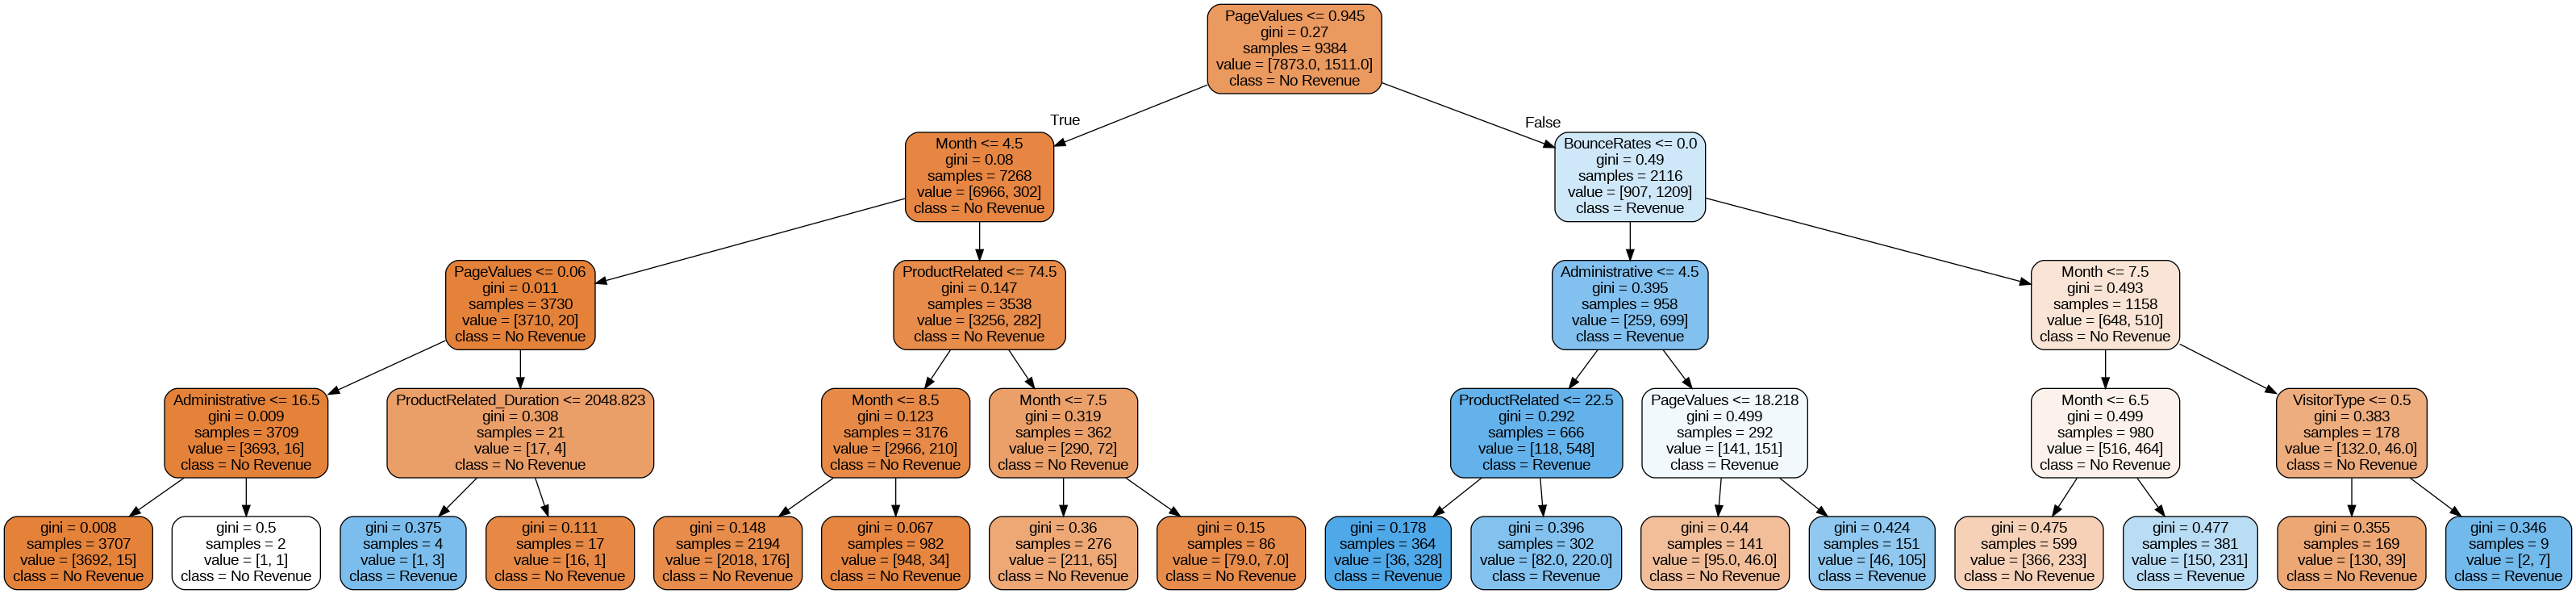

In [ ]:
from IPython.display import Image
export_graphviz(
    dt_best, out_file='tree_c.dot',
    feature_names=df.columns[:-1].values,
    class_names=['No Revenue', 'Revenue'],
    filled=True, rounded=True
)
!dot -Tpng tree_c.dot > tree_c.png
Image(filename='tree_c.png')

---
## 4. Random Forest Classifier  (tuning: n_estimators)

In [ ]:
n_trees = [2,3,4,5,6,7,8,9,10]
rf_results = {}

for n in n_trees:
    est = RandomForestClassifier(n_estimators=n, random_state=21)
    est.fit(X_train, y_train)
    acc = accuracy_score(est.predict(X_test), y_test)
    rf_results[n] = acc
    print(f'  n_estimators={n:>4} -> accuracy = {acc:.4f}')

best_n = n_trees[int(np.argmax(list(rf_results.values())))]
print(f'\nMejor n_estimators: {best_n}')

  n_estimators=   2 -> accuracy = 0.8623
  n_estimators=   3 -> accuracy = 0.8636
  n_estimators=   4 -> accuracy = 0.8747
  n_estimators=   5 -> accuracy = 0.8781
  n_estimators=   6 -> accuracy = 0.8815
  n_estimators=   7 -> accuracy = 0.8794
  n_estimators=   8 -> accuracy = 0.8819
  n_estimators=   9 -> accuracy = 0.8866
  n_estimators=  10 -> accuracy = 0.8870

Mejor n_estimators: 10


In [ ]:
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=21)
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)

print('=== Random Forest - Reporte de Clasificacion ===')
print(classification_report(y_test, y_pred_rf))

=== Random Forest - Reporte de Clasificacion ===
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1949
           1       0.73      0.52      0.61       397

    accuracy                           0.89      2346
   macro avg       0.82      0.74      0.77      2346
weighted avg       0.88      0.89      0.88      2346



---
## 5. SVM  (kernels: linear / poly / rbf)

In [ ]:
# SVM es sensible a la escala -> normalizamos
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

kernels = ['linear', 'poly', 'rbf']
svm_results = {}

for k in kernels:
    est = SVC(kernel=k, random_state=21)
    est.fit(X_train_sc, y_train)
    acc = accuracy_score(est.predict(X_test_sc), y_test)
    svm_results[k] = acc
    print(f'  kernel={k:<8} -> accuracy = {acc:.4f}')

best_kernel = max(svm_results, key=svm_results.get)
print(f'\nMejor kernel: {best_kernel}')

  kernel=linear   -> accuracy = 0.8824
  kernel=poly     -> accuracy = 0.8841
  kernel=rbf      -> accuracy = 0.8909

Mejor kernel: rbf


In [ ]:
svm_best = SVC(kernel=best_kernel, random_state=21)
svm_best.fit(X_train_sc, y_train)
y_pred_svm = svm_best.predict(X_test_sc)

print(f'=== SVM ({best_kernel}) - Reporte de Clasificacion ===')
print(classification_report(y_test, y_pred_svm))

=== SVM (rbf) - Reporte de Clasificacion ===
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      1949
           1       0.78      0.49      0.60       397

    accuracy                           0.89      2346
   macro avg       0.84      0.73      0.77      2346
weighted avg       0.88      0.89      0.88      2346



---
## 6. Cross-Validation  (k = 10)

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=21)

# Escala global para SVM en CV
scaler_cv = StandardScaler()
X_sc = scaler_cv.fit_transform(X)

cv_configs = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=best_depth, random_state=21), X),
    ('Random Forest', RandomForestClassifier(n_estimators=best_n,  random_state=21), X),
    ('SVM',          SVC(kernel=best_kernel, random_state=21),                       X_sc),
]

cv_scores = {}
print('=== Cross-Validation k=10 ===')
for name, model, Xeval in cv_configs:
    s = cross_val_score(model, Xeval, y, cv=kf, scoring=make_scorer(accuracy_score))
    cv_scores[name] = s
    print(f'  {name:<22} -> {np.mean(s):.4f} (+/- {np.std(s):.5f})')

=== Cross-Validation k=10 ===
  Decision Tree          -> 0.8888 (+/- 0.00756)
  Random Forest          -> 0.8904 (+/- 0.00558)
  SVM                    -> 0.8889 (+/- 0.00952)


---
## 7. Deep Learning - Perceptron Multicapa (3 arquitecturas)

| Arquitectura | Capas ocultas | Neuronas |
|---|---|---|
| DL-A | 3 | 64-128-128 |
| DL-B | 6 | 64-64-128-128-256-256 |
| DL-C | 10 | 128x10 |

In [ ]:
# Normalizar para DL
sc_dl = StandardScaler()
X_train_dl = sc_dl.fit_transform(X_train)
X_test_dl  = sc_dl.transform(X_test)

# One-hot para binary_crossentropy
y_train_ohe = to_categorical(y_train, num_classes=2)
y_test_ohe  = to_categorical(y_test,  num_classes=2)

n_features = X_train_dl.shape[1]
EPOCHS = 50
BATCH  = 64
print(f'Entradas: {n_features}  |  Epochs: {EPOCHS}  |  Batch: {BATCH}')

Entradas: 13  |  Epochs: 50  |  Batch: 64


In [ ]:
def build_model(hidden_layers, input_dim, n_classes=2):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(keras.layers.Dense(units, activation='relu'))
    model.add(keras.layers.Dense(n_classes, activation='softmax'))
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

architectures = {
    'DL-A (3 capas: 64-128-128)':            [64, 128, 128],
    'DL-B (6 capas: 64-64-128-128-256-256)': [64, 64, 128, 128, 256, 256],
    'DL-C (10 capas: 128x10)':               [128]*10,
}

dl_histories = {}
dl_scores    = {}

for name, layers in architectures.items():
    print(f'\n{"="*55}')
    print(f'  Entrenando: {name}')
    print('='*55)
    model = build_model(layers, n_features)
    model.summary()
    history = model.fit(
        X_train_dl, y_train_ohe,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_data=(X_test_dl, y_test_ohe),
        verbose=1
    )
    dl_histories[name] = history
    _, test_acc = model.evaluate(X_test_dl, y_test_ohe, verbose=0)
    dl_scores[name] = test_acc
    print(f'  -> Test accuracy: {test_acc:.4f}')


  Entrenando: DL-A (3 capas: 64-128-128)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,986 (101.51 KB)

 Trainable params: 25,986 (101.51 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,658 (588.51 KB)

 Trainable params: 150,658 (588.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8680 - loss: 0.3241 - val_accuracy: 0.8858 - val_loss: 0.2789
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8900 - loss: 0.2610 - val_accuracy: 0.8870 - val_loss: 0.2752
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8903 - loss: 0.2537 - val_accuracy: 0.8892 - val_loss: 0.2718
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8942 - loss: 0.2472 - val_accuracy: 0.8896 - val_loss: 0.2688
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8942 - loss: 0.2447 - val_accuracy: 0.8870 - val_loss: 0.2621
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8970 - loss: 0.2398 - val_accuracy: 0.8887 - val_loss: 0.2740
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8975 - loss: 0.2411 - val_accuracy: 0.8913 - val_loss: 0.2690
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8974 - loss: 0.2383 - val_accuracy: 0

---
## 8. Graficas comparativas

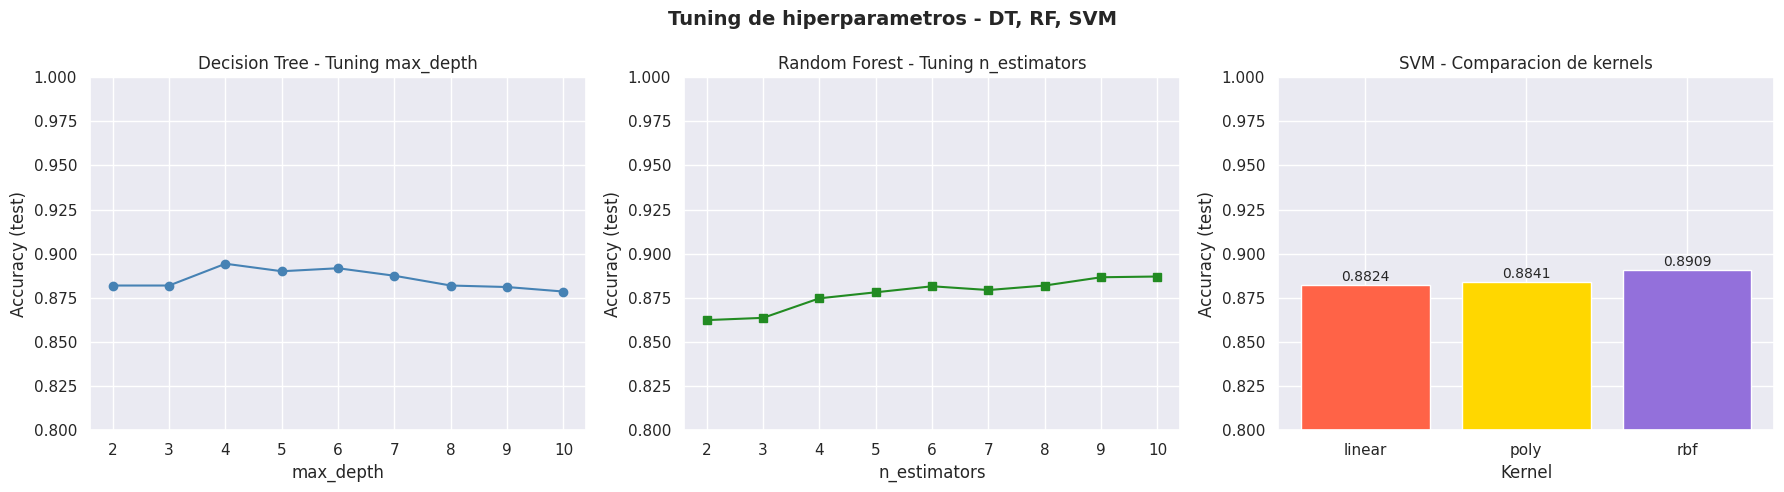

In [ ]:
# 8.1 Tuning DT, RF, SVM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot([str(d) for d in depths], list(dt_results.values()), marker='o', color='steelblue')
ax.set_title('Decision Tree - Tuning max_depth')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy (test)')
ax.set_ylim(0.8, 1.0)
ax.grid(True)

ax = axes[1]
ax.plot(list(rf_results.keys()), list(rf_results.values()), marker='s', color='forestgreen')
ax.set_title('Random Forest - Tuning n_estimators')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Accuracy (test)')
ax.set_ylim(0.8, 1.0)
ax.grid(True)

ax = axes[2]
bars = ax.bar(list(svm_results.keys()), list(svm_results.values()),
              color=['tomato', 'gold', 'mediumpurple'])
ax.set_title('SVM - Comparacion de kernels')
ax.set_xlabel('Kernel')
ax.set_ylabel('Accuracy (test)')
ax.set_ylim(0.8, 1.0)
for i, (k, v) in enumerate(svm_results.items()):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Tuning de hiperparametros - DT, RF, SVM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10483/2325909281.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_cv, labels=labels_cv, patch_artist=True,


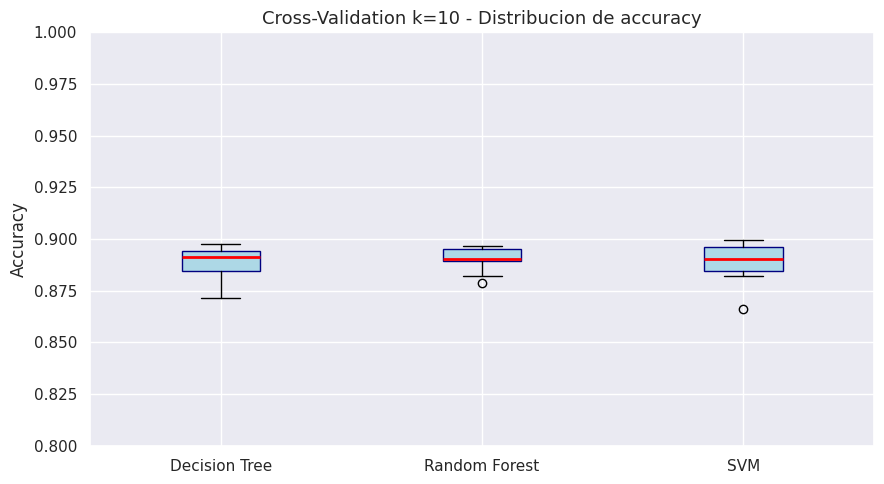

In [ ]:
# 8.2 Cross-Validation boxplot
fig, ax = plt.subplots(figsize=(9, 5))
data_cv   = [cv_scores[n] for n in cv_scores]
labels_cv = list(cv_scores.keys())
ax.boxplot(data_cv, labels=labels_cv, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Cross-Validation k=10 - Distribucion de accuracy', fontsize=13)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.0)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

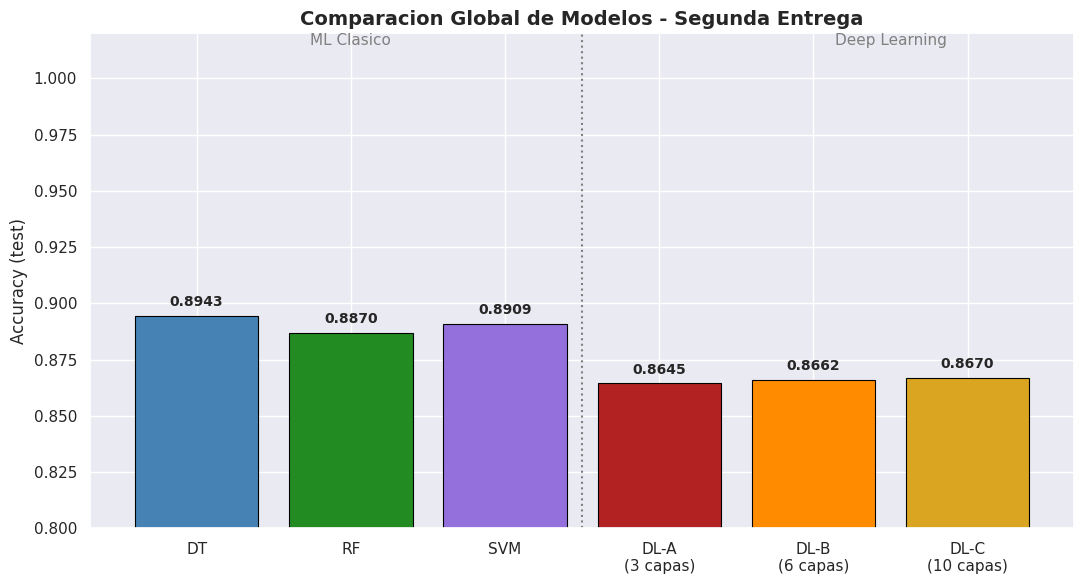

In [ ]:
# 8.3 Comparacion global DT / RF / SVM / DL
all_names = ['DT', 'RF', 'SVM', 'DL-A\n(3 capas)', 'DL-B\n(6 capas)', 'DL-C\n(10 capas)']
ml_acc    = [dt_results[str(best_depth)], rf_results[best_n], svm_results[best_kernel]]
dl_acc    = [dl_scores[n] for n in dl_scores]
all_acc   = ml_acc + dl_acc

palette = ['steelblue', 'forestgreen', 'mediumpurple', 'firebrick', 'darkorange', 'goldenrod']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(all_names, all_acc, color=palette, edgecolor='black', linewidth=0.8)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Accuracy (test)', fontsize=12)
ax.set_title('Comparacion Global de Modelos - Segunda Entrega', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, all_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axvline(2.5, color='gray', linestyle=':', linewidth=1.5)
ax.text(1.0, 1.015, 'ML Clasico',    ha='center', fontsize=11, color='gray')
ax.text(4.5, 1.015, 'Deep Learning', ha='center', fontsize=11, color='gray')
plt.tight_layout()
plt.show()

---
## 9. Resumen de resultados

In [ ]:
print('Modelo               | Accuracy test')
print('-'*40)
print(f'Decision Tree        | {dt_results[str(best_depth)]:.4f}')
print(f'Random Forest        | {rf_results[best_n]:.4f}')
print(f'SVM ({best_kernel:<6})       | {svm_results[best_kernel]:.4f}')
print('-'*40)
print(f'CV k=10 DT  mean     | {np.mean(cv_scores["Decision Tree"]):.4f} +/- {np.std(cv_scores["Decision Tree"]):.5f}')
print(f'CV k=10 RF  mean     | {np.mean(cv_scores["Random Forest"]):.4f} +/- {np.std(cv_scores["Random Forest"]):.5f}')
print(f'CV k=10 SVM mean     | {np.mean(cv_scores["SVM"]):.4f} +/- {np.std(cv_scores["SVM"]):.5f}')
print('-'*40)
for name, acc in dl_scores.items():
    print(f'{name[:20]:<20} | {acc:.4f}')

Modelo               | Accuracy test
----------------------------------------
Decision Tree        | 0.8943
Random Forest        | 0.8870
SVM (rbf   )       | 0.8909
----------------------------------------
CV k=10 DT  mean     | 0.8888 +/- 0.00756
CV k=10 RF  mean     | 0.8904 +/- 0.00558
CV k=10 SVM mean     | 0.8889 +/- 0.00952
----------------------------------------
DL-A (3 capas: 64-12 | 0.8645
DL-B (6 capas: 64-64 | 0.8662
DL-C (10 capas: 128x | 0.8670


---
#Tercera Entrega

---
#1. Reduccion de Dimensionalidad

In [ ]:
from sklearn.decomposition import PCA

pca_p = PCA(n_components=2)
X_pca = pca_p.fit_transform(X)
print('X sin pca', X.shape, 'X con pca', X_pca.shape)

X sin pca (11730, 13) X con pca (11730, 2)


---
#2. Aplicacion de KMeans

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)
kmeans.fit(X_pca)

KMeans(n_clusters=2)

---
#3. Aplicacion de DBScan

In [ ]:
from sklearn.cluster import DBSCAN

DBS = DBSCAN(eps=500, min_samples=5)
DBS.fit(X_pca)

DBSCAN(eps=500)

---
#4. Observacion de Resultados

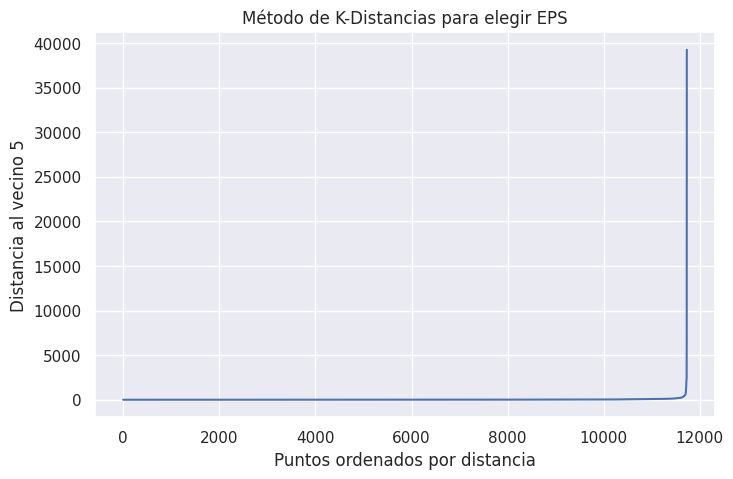

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos el número de vecinos
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

# 2. Ordenamos las distancias al k-ésimo vecino de menor a mayor
distances = np.sort(distances[:, k-1], axis=0)

# 3. Graficamos
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("Método de K-Distancias para elegir EPS")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al vecino {k}")
plt.grid(True)
plt.show()

/tmp/ipykernel_5470/2230372490.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", cmap='rainbow');


Text(0.5, 1.0, 'DBScan')

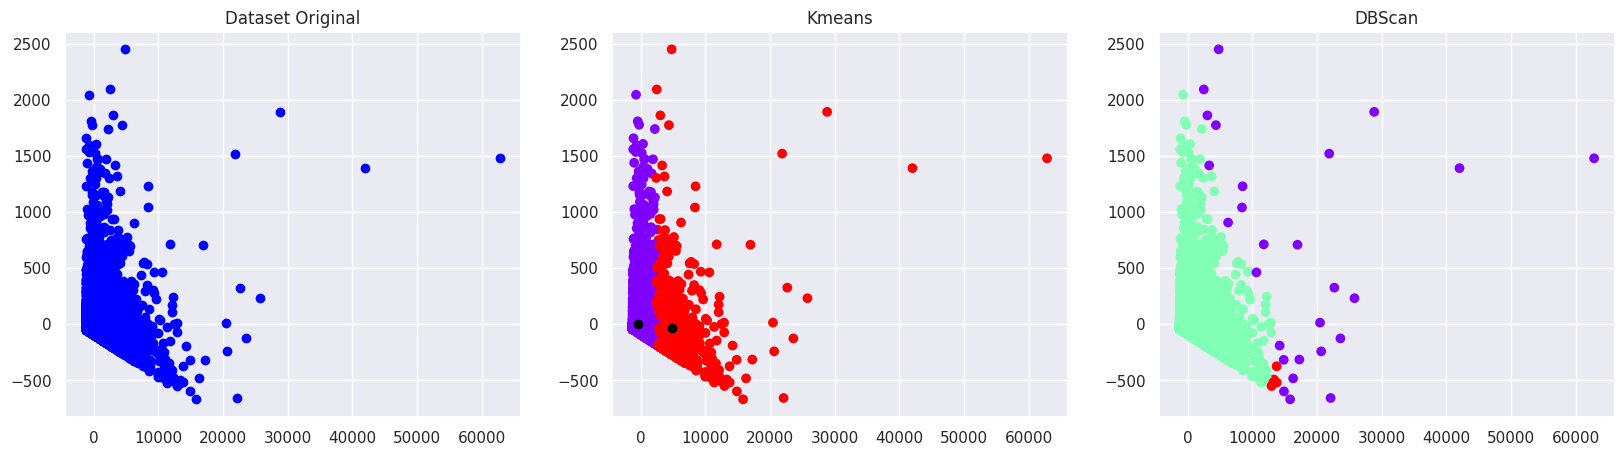

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(131)
plt.scatter(X_pca[:,0], X_pca[:,1], c="blue", cmap='rainbow');
plt.title('Dataset Original')
plt.subplot(132)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans.labels_, cmap='rainbow');
plt.title('Kmeans')
plt.scatter(kmeans.cluster_centers_[:,0] ,kmeans.cluster_centers_[:,1], color='black')
plt.subplot(133)
plt.scatter(X_pca[:,0], X_pca[:,1], c=DBS.labels_, cmap='rainbow')
plt.title('DBScan')

In [ ]:
# Agregar las etiquetas de DBSCAN al dataframe original
df['Cluster'] = DBS.labels_

# Ver cuántos Revenue=True hay en cada cluster
print(df.groupby('Cluster')['Revenue'].value_counts())

Cluster  Revenue
-1       0            17
         1            10
 0       0          9801
         1          1896
 1       0             4
         1             2
Name: count, dtype: int64
